## Insurance claims & Customer Risks Project

## Project Overview


This project focuses on analyzing insurance claims and customer risk using policy-level and claim-level data.

The analysis combines two datasets:

* **Frequency dataset:** contains policy-level information such as driver age, vehicle age, exposure, bonus-malus, and claim count.
* **Severity dataset:** contains individual claim amounts associated with each policy.

The datasets are cleaned and validated separately, claim amounts are aggregated at the policy level, and the two datasets are then merged using `IDpol`.

The final analysis focuses on customer and vehicle segmentation, exploratory data analysis, insurance KPIs, risk patterns, outlier review, and preparation of analysis-ready tables for visualization in Tableau.


## Project Objective


The main objectives of this project are to:

* Clean and validate the Frequency and Severity datasets.
* Verify the consistency of claim counts between the two datasets.
* Aggregate claim amounts at the policy level.
* Merge policy and claim information using `IDpol`.
* Create meaningful driver age, vehicle age, and bonus-malus segments.
* Explore distributions, skewness, and potential outliers.
* Calculate insurance portfolio and segment-level KPIs.
* Identify patterns in claims and customer risk.
* Prepare clean analysis tables for Tableau visualization.


## Dataset Overview


The project uses two related insurance datasets:

### Frequency Dataset

Contains one record per insurance policy and includes policy characteristics, driver and vehicle information, exposure, bonus-malus, and the number of claims.

### Severity Dataset

Contains claim-level records and the corresponding claim amounts for policies with reported claims.

The two datasets are linked through the common policy identifier `IDpol`.


## Tools & Libraries


- Python
- Pandas
- NumPy
- Matplotlib
- Plotly

## Workflow


1. Load Frequency and Severity datasets


2. Inspect dataset structure and data types


3. Perform data quality checks


4. Clean and validate each dataset separately


5. Aggregate claim amounts by policy


6. Validate claim counts between Frequency and Severity datasets


7. Merge datasets using `IDpol`


8. Create driver age, vehicle age, and bonus-malus segments


9. Perform exploratory data analysis


10. Calculate portfolio and segment-level insurance KPIs


11. Review potential outliers and Pareto patterns


12. Export analysis-ready tables for Tableau


In [2]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

## Dataset information

In [3]:
#Load_data 

freq = pd.read_csv("../data/raw/freMTPL2freq.csv")
sev = pd.read_csv("../data/raw/freMTPL2sev.csv")

### Initial Inspection


The first few records and descriptive statistics are reviewed to understand the structure, scale, and basic characteristics of each dataset.


In [4]:
freq.head(3)

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,0,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,0,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,0,0.75,6,2,52,50,B12,Diesel,B,54,Picardie


In [5]:
freq.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,6.779910e+05,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000
mean,2.621886e+06,0.039003,0.528743,6.454649,7.044244,45.499092,59.761559,1792.406856
std,1.641776e+06,0.207169,0.364441,2.050914,5.666226,14.137449,15.636713,3958.574057
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157964e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272157e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046271e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


In [6]:
sev.head(3)

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11


In [7]:
sev.describe()

,IDpol,ClaimAmount
count,2.644400e+04,2.644400e+04
mean,2.280004e+06,2.265513e+03
std,1.583004e+06,2.937103e+04
min,1.390000e+02,1.000000e+00
25%,1.086381e+06,6.859925e+02
50%,2.133756e+06,1.172000e+03
75%,3.183953e+06,1.212385e+03
max,6.113971e+06,4.075401e+06


### Inspect Stracture / Types

In [8]:
print('freq shape :', freq.shape)
print('sev shape :', sev.shape)

freq shape : (677991, 12)
sev shape : (26444, 2)


In [9]:
def col_detail(df):
    col_name = []
    dtypes = []
    count = []
    unique = []

    for col in df.columns:
        col_name.append(col)
        dtypes.append(df[col].dtype)
        count.append(len(df[col]))
        unique.append(df[col].nunique())

    return pd.DataFrame({
        "Column_name": col_name,
        "Dtype": dtypes,
        "Count": count,
        "Unique": unique
    })

In [10]:
col_detail(freq)

,Column_name,Dtype,Count,Unique
0,IDpol,float64,677991,677991
1,ClaimNb,int64,677991,11
2,Exposure,float64,677991,181
3,VehPower,int64,677991,12
4,VehAge,int64,677991,78
5,DrivAge,int64,677991,83
6,BonusMalus,int64,677991,115
7,VehBrand,object,677991,11
8,VehGas,object,677991,2
9,Area,object,677991,6


In [11]:
col_detail(sev)

,Column_name,Dtype,Count,Unique
0,IDpol,int64,26444,24944
1,ClaimAmount,float64,26444,12255


## Data Cleaning - freq Dataset

### Missing Values

In [12]:
#number_of_missing_values

missing_freq = freq.isna().sum().sum()

print(f"number of missing values in freq: {missing_freq}")


number of missing values in freq: 0


### Duplicate Records

In [13]:
#number_of_duplicate_records

num_dup = freq.duplicated().sum()

if num_dup ==0:
    print("There is no duplicate records in freq dataset.")
elif num_dup ==1:
    print("There is one duplicate records in freq dataset.")
else:
    print(f"There are {num_dup} duplicate records in freq dataset.")

There is no duplicate records in freq dataset.


In [14]:
#Duplicate_IDpol

print("Duplicate IDpols in freq : ", freq["IDpol"].duplicated().sum())

Duplicate IDpols in freq :  0


### Data Types

In [15]:
freq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677991 entries, 0 to 677990
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       677991 non-null  float64
 1   ClaimNb     677991 non-null  int64  
 2   Exposure    677991 non-null  float64
 3   VehPower    677991 non-null  int64  
 4   VehAge      677991 non-null  int64  
 5   DrivAge     677991 non-null  int64  
 6   BonusMalus  677991 non-null  int64  
 7   VehBrand    677991 non-null  object 
 8   VehGas      677991 non-null  object 
 9   Area        677991 non-null  object 
 10  Density     677991 non-null  int64  
 11  Region      677991 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB


In [16]:
#IDpol
freq["IDpol"] = freq["IDpol"].astype(int)


### Invalid & Inconsistent Values

In [17]:
freq.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region'],
      dtype='object')

In [18]:
# ClaimNb should not be negative
print('ClaimNb < 0 :', (freq["ClaimNb"]<0).sum())

# Exposure should not be negative
print('Exposure < 0 :', (freq['Exposure']< 0).sum())

# VehPower should not be zero or negative
print('VehPower <= 0 :', (freq['VehPower']<=0).sum())

# VehAge should not be negative
print('VehAge < 0 :', (freq['VehAge']<0).sum())

# DrivAge should be between 18 and 100
print('DrivAge < 18 :', (freq['DrivAge']<18).sum())
print('DrivAge > 100 :', (freq['DrivAge']>100).sum())

# BonusMalus should not be negative
print('BonusMalus < 0 :', (freq["BonusMalus"]<0).sum())

# Density should not be negative
print('Density < 0 :', (freq["Density"]<0).sum())


ClaimNb < 0 : 0
Exposure < 0 : 0
VehPower <= 0 : 0
VehAge < 0 : 0
DrivAge < 18 : 0
DrivAge > 100 : 0
BonusMalus < 0 : 0
Density < 0 : 0


In [19]:
# Categorical Columns

def categorical_summary(freq):
    categorical_cols = freq.select_dtypes(include=['object','string']).columns
    for col in categorical_cols :
        print(f"\n{'_'*20}")
        print(f"Column Name :{col}")
        print(f"Unique Values : {freq[col].nunique(dropna=False)}")
        print(freq[col].value_counts(dropna= False))
        
        
categorical_summary(freq)


____________________
Column Name :VehBrand
Unique Values : 11
VehBrand
B12    166022
B1     162730
B2     159854
B3      53393
B5      34752
B6      28545
B4      25179
B10     17707
B11     13585
B13     12177
B14      4047
Name: count, dtype: int64

____________________
Column Name :VehGas
Unique Values : 2
VehGas
Regular    345863
Diesel     332128
Name: count, dtype: int64

____________________
Column Name :Area
Unique Values : 6
Area
C    191874
D    151592
E    137163
A    103952
B     75457
F     17953
Name: count, dtype: int64

____________________
Column Name :Region
Unique Values : 22
Region
Centre                         160595
Rhone-Alpes                     84748
Provence-Alpes-Cotes-D'Azur     79315
Ile-de-France                   69789
Bretagne                        42120
Pays-de-la-Loire                38747
Languedoc-Roussillon            35805
Aquitaine                       31329
Nord-Pas-de-Calais              27284
Poitou-Charentes                19046
Midi-Pyren

### Claim Count Distribution

In [20]:
print('ClaimNb = 0 :' , (freq["ClaimNb"]==0).sum())
print('ClaimNb > 0 :', (freq["ClaimNb"]>0).sum())

ClaimNb = 0 : 653047
ClaimNb > 0 : 24944


In [21]:
print(freq['ClaimNb'].value_counts().sort_index())

ClaimNb
0     653047
1      23571
2       1298
3         62
4          5
5          2
6          1
8          1
9          1
11         2
16         1
Name: count, dtype: int64


## Data Cleaning - sev Dataset

### Missing Values

In [22]:
#number_of_missing_values

missing_sev = sev.isna().sum().sum()

print(f"number of missing values in sev: {missing_sev}")

number of missing values in sev: 0


### duplicate Records

In [23]:
#number_of_duplicate_records

num_dup = sev.duplicated().sum()

if num_dup ==0:
    print("There is no duplicate records in sev dataset.")
elif num_dup ==1:
    print("There is one duplicate records in sev dataset.")
else:
    print(f"There are {num_dup} duplicate records in sev dataset.")

There are 235 duplicate records in sev dataset.


In [24]:
# Duplicate_records

duplicate_records = sev[sev.duplicated(keep=False)].sort_values("IDpol")

print(duplicate_records.head(20))

       IDpol  ClaimAmount
6355   18698      1128.12
5022   18698      1128.12
4514   19887      1128.12
4521   19887      1128.12
6322   24992      1128.12
6318   24992      1128.12
5862   25763      1128.12
5866   25763      1128.12
24094  29567      1128.12
24096  29567      1128.12
4456   47912      1128.12
4457   47912      1128.12
20862  54009      1128.12
21030  54009      1128.12
20115  57501      1128.12
19929  57501      1128.12
24212  58271      1128.12
24177  58271      1128.12
6358   63581      1128.12
5094   63581      1128.12


In [25]:
print("Policies with duplicate claim records:", duplicate_records["IDpol"].nunique())

Policies with duplicate claim records: 227


In [26]:
claims_per_policy = sev.groupby("IDpol").size()

print("Policies with >1 claim:", (claims_per_policy > 1).sum())

print("Policies with exactly 1 claim:", (claims_per_policy == 1).sum())

Policies with >1 claim: 1373
Policies with exactly 1 claim: 23571


In [27]:
print("Unique IDpol:", sev["IDpol"].nunique())
print("Total rows:", len(sev))
print("Duplicate IDpol:", sev["IDpol"].duplicated().sum())

Unique IDpol: 24944
Total rows: 26444
Duplicate IDpol: 1500


### Duplicate Record Assessment


A total of 235 exact duplicate records were identified in the Severity dataset.

However, the Severity dataset does not contain a unique claim identifier, so the duplicated records cannot be assumed to be erroneous records. 
The duplicate records were preserved because the Severity dataset does not contain a unique claim identifier, and the claim-level record count is fully consistent with ClaimNb in the Frequency dataset. Therefore, the records were not removed without additional evidence that they represented data errors.

In [28]:
claims_per_policy = sev.groupby("IDpol").size()

print(claims_per_policy.describe())

count    24944.000000
mean         1.060135
std          0.289868
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
dtype: float64


In [29]:
print(claims_per_policy.value_counts().sort_index())

1     23571
2      1298
3        62
4         5
5         2
6         1
8         1
9         1
11        2
16        1
Name: count, dtype: int64


In [30]:
print(sev["ClaimAmount"].describe())
print("ClaimAmount <= 0:", (sev["ClaimAmount"] <= 0).sum())

count    2.644400e+04
mean     2.265513e+03
std      2.937103e+04
min      1.000000e+00
25%      6.859925e+02
50%      1.172000e+03
75%      1.212385e+03
max      4.075401e+06
Name: ClaimAmount, dtype: float64
ClaimAmount <= 0: 0


In [31]:
print(
    sev.nlargest(10, "ClaimAmount")[["IDpol", "ClaimAmount"]]
)

         IDpol  ClaimAmount
9756   1120377   4075400.56
15768   110846   1403057.40
11637  2141337   1301172.60
17992  3122016    774411.50
2869   2008127    390742.27
3307   3025890    369131.88
9999   1117644    307096.42
5521    158309    301635.49
18627  3075820    287423.00
18295  3150210    281897.49


In [32]:
duplicate_records.groupby(["IDpol", "ClaimAmount"]).size().sort_values(ascending=False).head(20)

IDpol    ClaimAmount
93954    1128.12        4
3253234  1500.00        3
2277762  1500.00        3
4186720  1204.00        3
4126439  1204.00        3
3156096  1204.00        2
3140888  1204.00        2
3141835  1204.00        2
3143793  1204.00        2
3144670  1204.00        2
3146197  1204.00        2
3146671  1204.00        2
3148279  1204.00        2
3149933  1204.00        2
3150325  1204.00        2
3153801  1204.00        2
3162581  1204.00        2
3157425  1204.00        2
3133779  1204.00        2
3166102  1204.00        2
dtype: int64

## Dataset Validation

In [33]:
# Number of claim records for each policy in Severity
sev_claim_count = sev.groupby("IDpol").size()

# Compare ClaimNb from Frequency with claim count from Severity
comparison = freq[["IDpol", "ClaimNb"]].copy()

comparison["Severity_Claim_Count"] = (comparison["IDpol"].map(sev_claim_count).fillna(0).astype(int))

# Check whether the two values match
comparison["Match"] = (comparison["ClaimNb"] == comparison["Severity_Claim_Count"])

# Summary
print("Matching policies:", comparison["Match"].sum())
print("Mismatching policies:", (~comparison["Match"]).sum())

Matching policies: 677991
Mismatching policies: 0


### Claim Count Validation

The number of claim records per policy in the Severity dataset was compared with `ClaimNb` from the Frequency dataset.

All 677,991 policies showed matching claim counts, with **0 mismatches**.

This confirms that the claim-level records in the Severity dataset are consistent with the policy-level claim counts in the Frequency dataset.


## Aggregate Claim Amounts


Since the Severity dataset contains claim-level records, a policy may appear multiple times when it has multiple claims.

To create a policy-level dataset, claim amounts are summed by `IDpol`. This produces one record per policy with the total claim amount represented by `TotalClaimAmount`.

Average Claim Severity = Average total claim cost per policy among policies with observed claims.

In [34]:
sev_ag = (sev.groupby("IDpol", as_index=False)["ClaimAmount"].sum().rename(columns={"ClaimAmount": "TotalClaimAmount"}))

In [35]:
sev_ag.shape

(24944, 2)

In [36]:
sev_ag.head()

,IDpol,TotalClaimAmount
0,139,303.00
1,190,1981.84
2,414,1456.55
3,424,10834.00
4,463,3986.67


In [37]:
print("Unique IDpol in aggregated Severity:", sev_ag["IDpol"].nunique())
print("Rows in aggregated Severity:", len(sev_ag))
print("Duplicate IDpol:", sev_ag["IDpol"].duplicated().sum())
print("Missing TotalClaimAmount:", sev_ag["TotalClaimAmount"].isna().sum())

Unique IDpol in aggregated Severity: 24944
Rows in aggregated Severity: 24944
Duplicate IDpol: 0
Missing TotalClaimAmount: 0


## Merge Datasets

In [38]:
merged = freq.merge(sev_ag, on='IDpol', how= 'left')

In [39]:
#Number_of_Rows_Columns

rows,columns= merged.shape
print(f"Number of rows in this dataset is: {rows}")
print(f"Number of columns in this dataset is: {columns}")

Number of rows in this dataset is: 677991
Number of columns in this dataset is: 13


In [40]:
print('Duplicate IDpol : ', merged['IDpol'].duplicated().sum())

Duplicate IDpol :  0



To support segment-level risk analysis, three business-oriented segments are created based on driver age, vehicle age, and bonus-malus.

* **Age Segment:** groups drivers by age range.
* **Vehicle Age Segment:** groups vehicles based on vehicle age.
* **Bonus-Malus Segment:** groups policies based on the bonus-malus value.

These segments will later be used to compare insurance KPIs and claim patterns across different customer and risk groups.


## Segmentation

In [41]:
print(merged[['DrivAge', 'VehAge', 'BonusMalus']].describe())

             DrivAge         VehAge     BonusMalus
count  677991.000000  677991.000000  677991.000000
mean       45.499092       7.044244      59.761559
std        14.137449       5.666226      15.636713
min        18.000000       0.000000      50.000000
25%        34.000000       2.000000      50.000000
50%        44.000000       6.000000      50.000000
75%        55.000000      11.000000      64.000000
max       100.000000     100.000000     230.000000


In [42]:
merged["AgeSegment"] = pd.cut(
    merged["DrivAge"],
    bins=[17, 25, 35, 50, 65, float("inf")],
    labels=["18-25", "26-35", "36-50", "51-65", "66+"])

merged["VehicleAgeSegment"] = pd.cut(
    merged["VehAge"],
    bins=[-1, 5, 10, 15, float("inf")],
    labels=["0-5", "6-10", "11-15", "16+"])

merged["BonusMalusSegment"] = pd.cut(
    merged["BonusMalus"],
    bins=[49, 50, 64, 100, 150, float("inf")],
    labels=["50", "51-64", "65-100", "101-150", "151+"])

In [43]:
for col in ["AgeSegment", "VehicleAgeSegment", "BonusMalusSegment"]:
    print(f"\n{col}")
    print(merged[col].value_counts().sort_index())


AgeSegment
AgeSegment
18-25     38893
26-35    149180
36-50    251685
51-65    171242
66+       66991
Name: count, dtype: int64

VehicleAgeSegment
VehicleAgeSegment
0-5      320628
6-10     171587
11-15    134059
16+       51717
Name: count, dtype: int64

BonusMalusSegment
BonusMalusSegment
50         384142
51-64      124708
65-100     161347
101-150      7585
151+          209
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

### Histogram

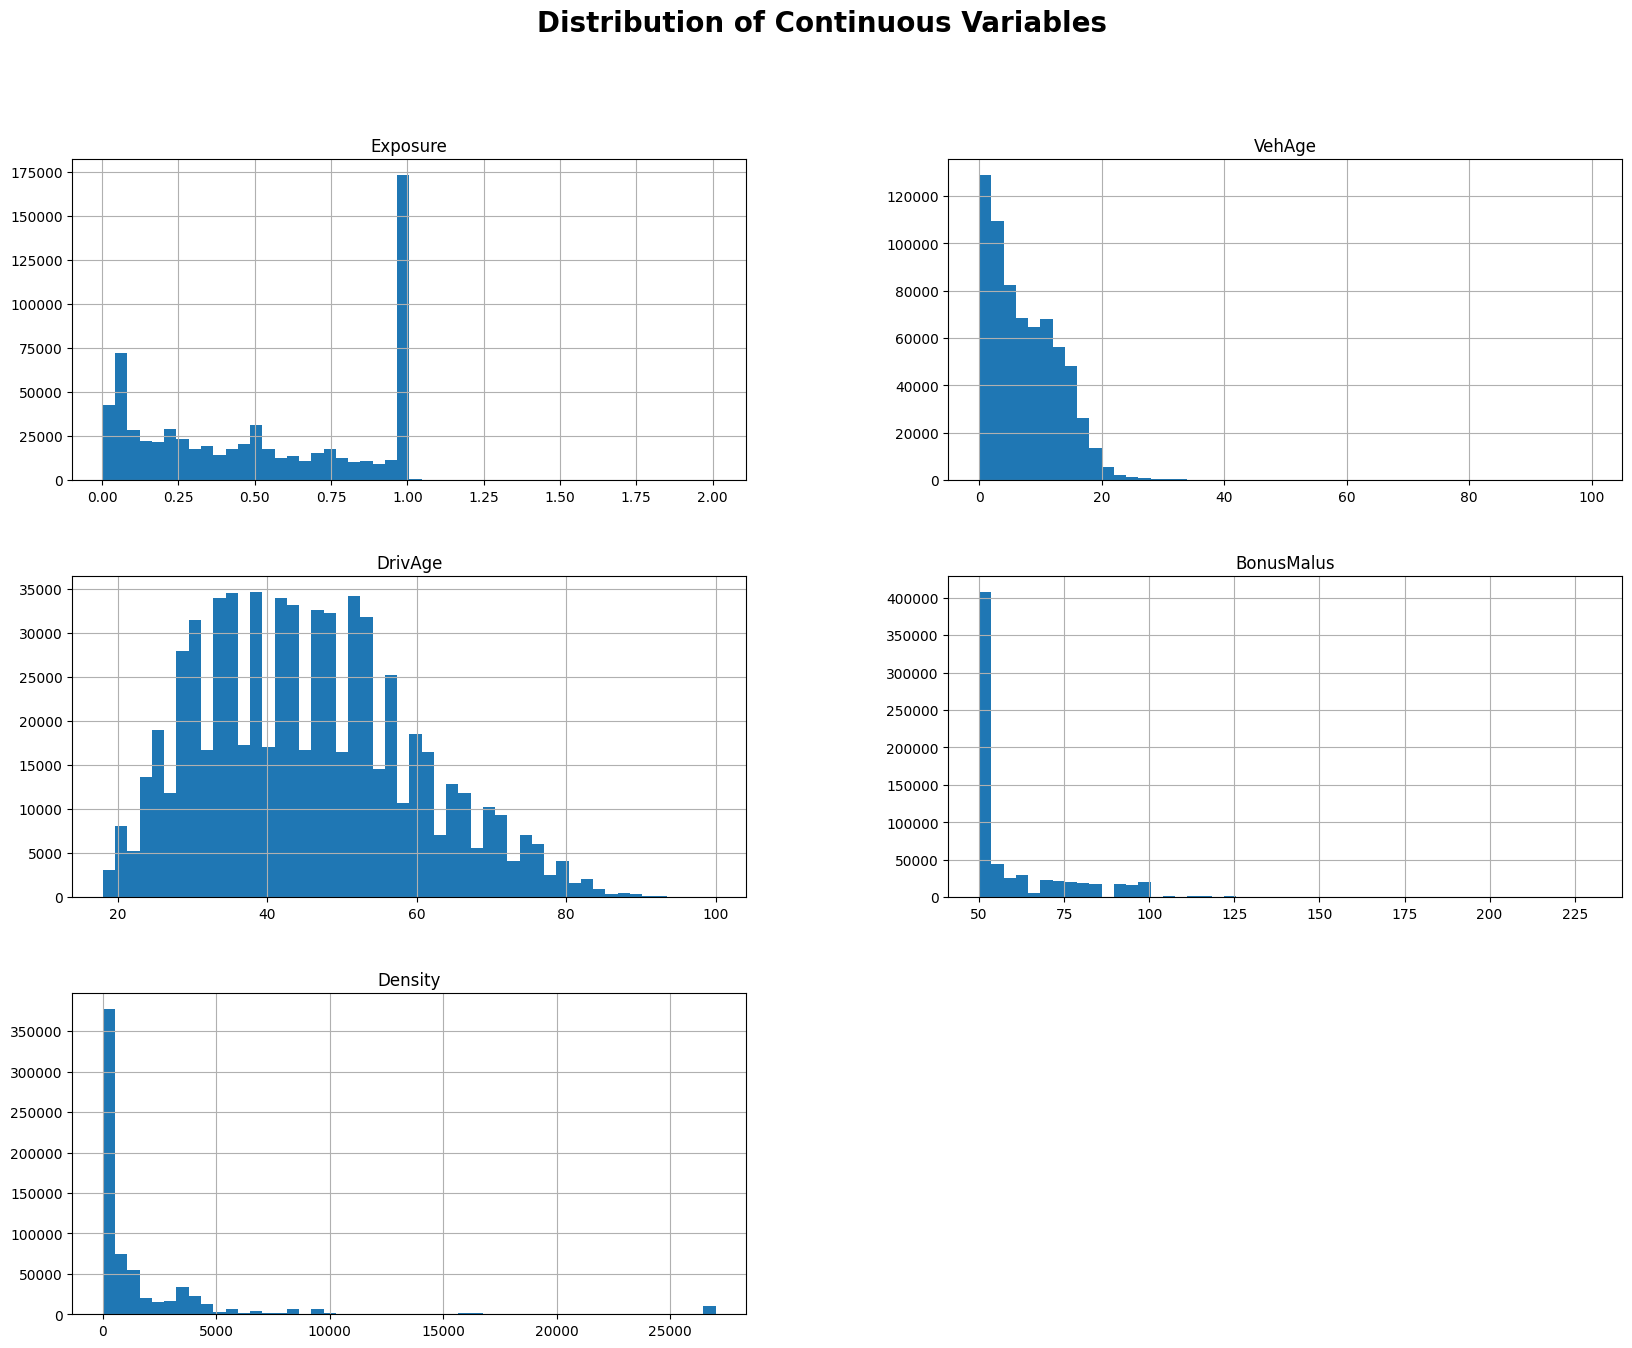

In [44]:
#Initial_Distribution_Check

#Continuous_columns
cont_cols = ["Exposure","VehAge","DrivAge","BonusMalus", "Density"]

#Histogram
merged[cont_cols].hist(bins=50, figsize=(20, 15))
plt.suptitle("Distribution of Continuous Variables", fontsize=20, fontweight='bold')
plt.show()

### Distribution Insights


The distributions show different patterns across the continuous variables.

`VehAge` is moderately right-skewed (skewness ≈ 1.15), while Density is highly right-skewed (skewness ≈ 4.65). This indicates that most policies are associated with relatively low vehicle ages and lower-density areas, with a smaller number of observations extending toward much higher values.

`DrivAge` is relatively concentrated around middle-aged drivers, while `VehAge` is right-skewed, indicating that most vehicles are relatively young with fewer observations at higher vehicle ages.

`Density` is highly right-skewed, suggesting that most policies are associated with lower-density areas, while a smaller number of policies are associated with areas with substantially higher population density.

`BonusMalus` is concentrated around the lower end of its range, particularly at 50, with relatively few observations at higher values.

`Exposure` represents the duration of policy exposure and should be interpreted as a measure of time at risk rather than a simple customer characteristic.



### Total Claim Amount Distribution

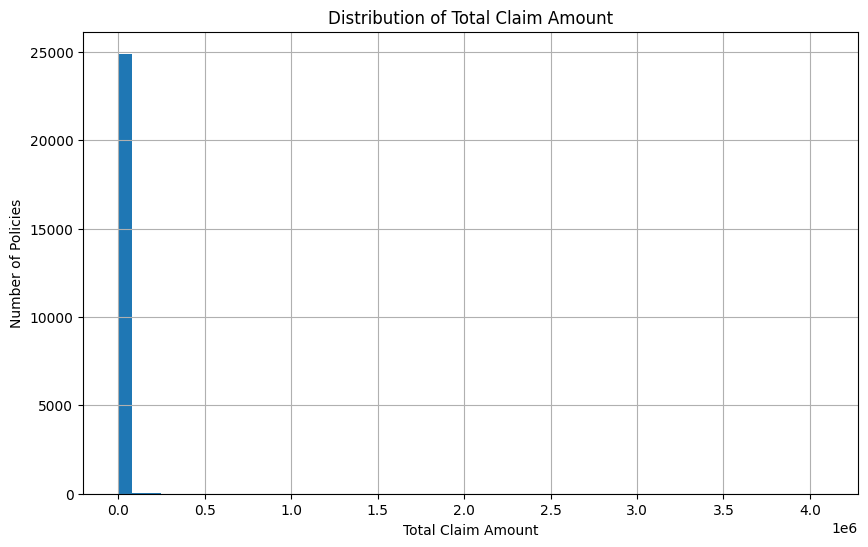

In [45]:
# Distribution of Total Claim Amount

merged["TotalClaimAmount"].hist(bins=50, figsize=(10, 6))

plt.title("Distribution of Total Claim Amount")
plt.xlabel("Total Claim Amount")
plt.ylabel("Number of Policies")
plt.show()

In [46]:
print("TotalClaimAmount skewness:", merged["TotalClaimAmount"].skew())

TotalClaimAmount skewness: 106.14445920005171



`TotalClaimAmount` is extremely right-skewed (skewness ≈ 106.14). Most policies have relatively low total claim costs, while a small number of policies have exceptionally high claim amounts.

These extreme values are retained because a high claim amount is not necessarily a data error and may represent genuine high-severity insurance losses.


### Skewness

In [47]:
merged[cont_cols].skew().sort_values(ascending=False)

Density       4.651450
BonusMalus    1.728934
VehAge        1.148011
DrivAge       0.435773
Exposure      0.085351
dtype: float64

### Claim Rate by Age Segment

In [48]:
merged["HasClaim"] = (merged["ClaimNb"] > 0).astype(int)

In [49]:
claim_rate_age = (
    merged.groupby("AgeSegment", observed=True)["HasClaim"]
    .mean()
    .mul(100)
    .reset_index(name="ClaimRate"))

claim_rate_age

,AgeSegment,ClaimRate
0,18-25,5.710539
1,26-35,3.275238
2,36-50,3.653376
3,51-65,3.604840
4,66+,3.685570


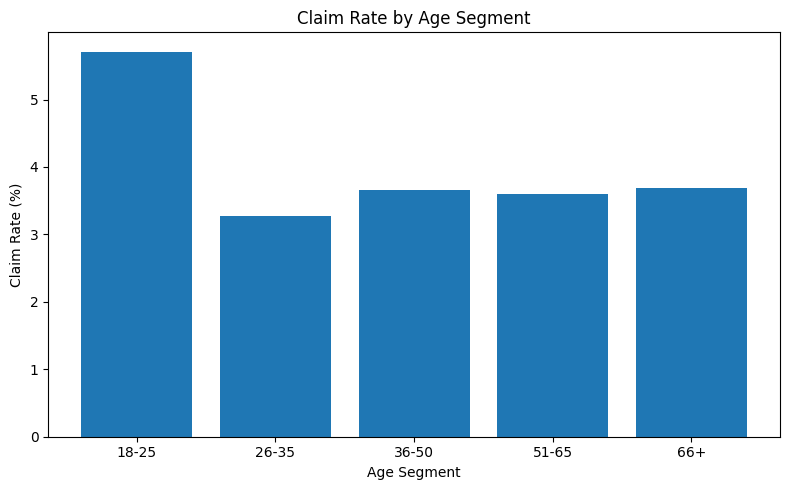

In [50]:
plt.figure(figsize=(8, 5))

plt.bar(claim_rate_age["AgeSegment"], claim_rate_age["ClaimRate"])

plt.title("Claim Rate by Age Segment")
plt.xlabel("Age Segment")
plt.ylabel("Claim Rate (%)")

plt.tight_layout()
plt.show()

### Claim Rate by Vehicle Age Segment

In [51]:
claim_rate_vehicle_age = (
    merged.groupby("VehicleAgeSegment", observed=True)["HasClaim"]
    .mean()
    .mul(100)
    .reset_index(name="ClaimRate"))

claim_rate_vehicle_age

,VehicleAgeSegment,ClaimRate
0,0-5,3.242699
1,6-10,4.415836
2,11-15,4.005699
3,16+,3.093760


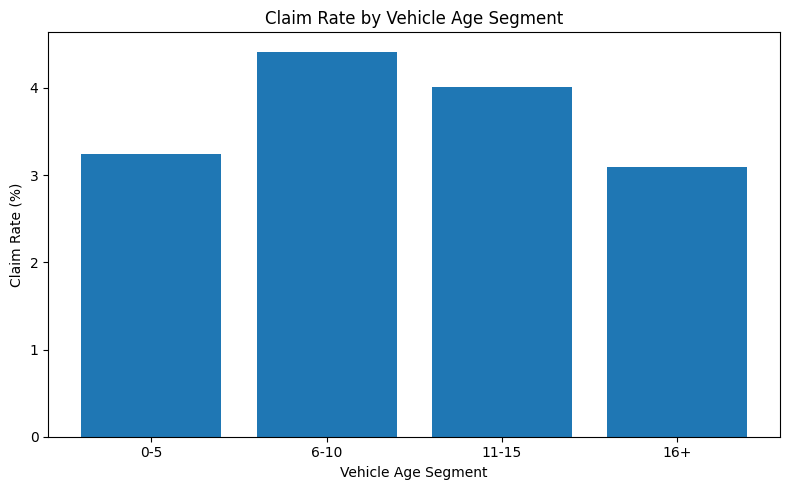

In [52]:
plt.figure(figsize=(8, 5))

plt.bar(
    claim_rate_vehicle_age["VehicleAgeSegment"],
    claim_rate_vehicle_age["ClaimRate"])

plt.title("Claim Rate by Vehicle Age Segment")
plt.xlabel("Vehicle Age Segment")
plt.ylabel("Claim Rate (%)")

plt.tight_layout()
plt.show()

### Claim Rate by Bonus-Malus Segment

In [53]:
claim_rate_bonus = (
    merged.groupby("BonusMalusSegment", observed=True)["HasClaim"]
    .mean()
    .mul(100)
    .reset_index(name="ClaimRate"))

claim_rate_bonus

,BonusMalusSegment,ClaimRate
0,50,2.876801
1,51-64,4.185778
2,65-100,4.672538
3,101-150,14.423204
4,151+,19.138756


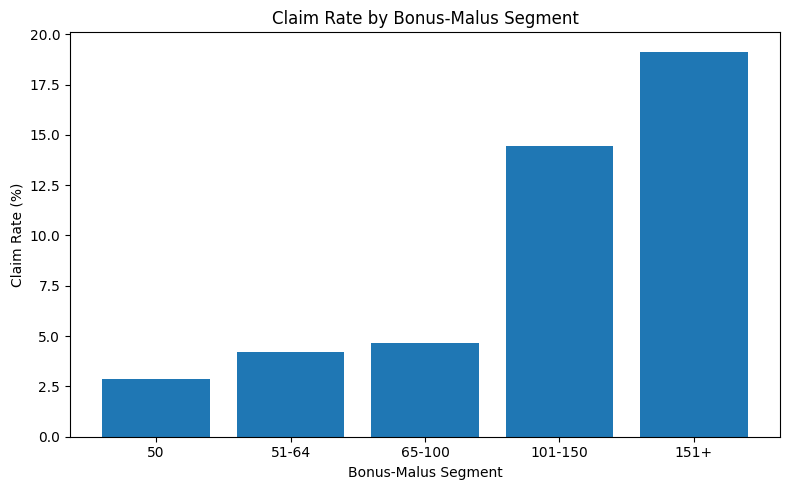

In [54]:
plt.figure(figsize=(8, 5))

plt.bar(
    claim_rate_bonus["BonusMalusSegment"],
    claim_rate_bonus["ClaimRate"])

plt.title("Claim Rate by Bonus-Malus Segment")
plt.xlabel("Bonus-Malus Segment")
plt.ylabel("Claim Rate (%)")

plt.tight_layout()
plt.show()

Higher Bonus-Malus segments are associated with substantially higher claim rates, with a particularly sharp increase above 100.

### Top policies by Total Claim Amount

In [55]:
top_policies = (sev_ag.sort_values("TotalClaimAmount", ascending=False).head(10).reset_index(drop=True))

top_policies

,IDpol,TotalClaimAmount
0,1120377,4075400.56
1,110846,1404185.52
2,2141337,1301172.60
3,3122016,774411.50
4,2008127,399213.66
5,3025890,382955.14
6,1117644,307096.42
7,158309,301635.49
8,3075820,287423.00
9,3150210,281897.49


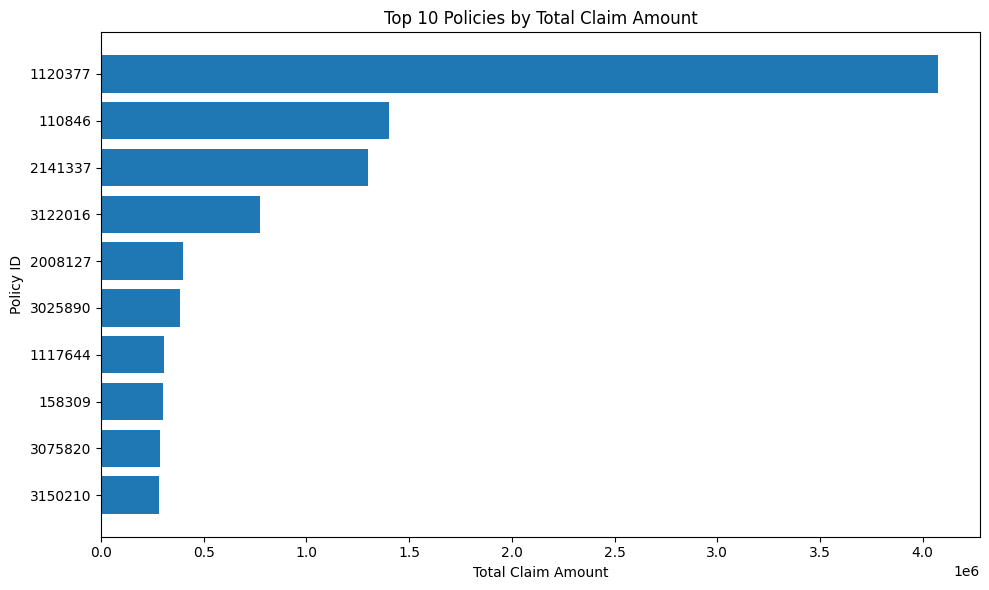

In [56]:
plt.figure(figsize=(10, 6))

plt.barh(top_policies["IDpol"].astype(str),top_policies["TotalClaimAmount"])

plt.title("Top 10 Policies by Total Claim Amount")
plt.xlabel("Total Claim Amount")
plt.ylabel("Policy ID")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Region Analysis


Regions are compared using exposure, claim frequency, total claim cost, and average claim severity.

Claim frequency is normalized by exposure so that regions with different portfolio sizes or exposure periods can be compared more fairly. Total claim cost reflects the overall financial burden, while average claim severity reflects the average total claim cost among policies with observed claims.

The analysis is descriptive and does not imply that region causes higher or lower claim risk.

In [57]:
region_claims = (
    merged[["IDpol", "Region"]]
    .drop_duplicates("IDpol")
    .merge(
        sev_ag[["IDpol", "TotalClaimAmount"]],
        on="IDpol",
        how="inner"
    ))

region_cost = (
    region_claims
    .groupby("Region")
    .agg(
        TotalClaimCost=("TotalClaimAmount", "sum"),
        AverageClaimSeverity=("TotalClaimAmount", "mean")
    )
    .reset_index())

region_cost

,Region,TotalClaimCost,AverageClaimSeverity
0,Alsace,121424.99,1462.951687
1,Aquitaine,1916138.54,1945.318315
2,Auvergne,183974.83,1362.776519
3,Basse-Normandie,929847.31,2167.476247
4,Bourgogne,636298.04,1939.933049
5,Bretagne,3901051.25,2175.711796
6,Centre,19074802.36,3046.119828
7,Champagne-Ardenne,481248.34,6874.976286
8,Corse,464582.55,4262.225229
9,Franche-Comte,76534.11,2125.947500


In [58]:
region_kpis = (merged.groupby("Region").agg(
        PolicyCount=("IDpol", "nunique"),
        Exposure=("Exposure", "sum"),
        ClaimCount=("ClaimNb", "sum")
    )
    .reset_index())

region_kpis["ClaimFrequency"] = (region_kpis["ClaimCount"]/ region_kpis["Exposure"])

region_kpis = region_kpis.merge(region_cost,on="Region",how="left")

region_kpis

,Region,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageClaimSeverity
0,Alsace,2200,1209.115823,92,0.076089,121424.99,1462.951687
1,Aquitaine,31329,14322.166692,1055,0.073662,1916138.54,1945.318315
2,Auvergne,5287,2322.884229,141,0.060700,183974.83,1362.776519
3,Basse-Normandie,10892,6657.801142,452,0.067890,929847.31,2167.476247
4,Bourgogne,10491,5025.098609,345,0.068655,636298.04,1939.933049
5,Bretagne,42120,27752.443675,1871,0.067417,3901051.25,2175.711796
6,Centre,160595,102707.853386,6475,0.063043,19074802.36,3046.119828
7,Champagne-Ardenne,3025,1204.881509,77,0.063907,481248.34,6874.976286
8,Corse,4516,1765.935399,132,0.074748,464582.55,4262.225229
9,Franche-Comte,1326,564.012946,38,0.067374,76534.11,2125.947500


In [59]:
region_kpis.sort_values("ClaimFrequency",ascending=False)

,Region,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageClaimSeverity
21,Rhone-Alpes,84748,45343.547286,4233,0.093354,10278303.85,2568.291817
18,Picardie,7994,3574.410221,314,0.087847,687624.87,2276.903543
11,Ile-de-France,69789,30207.161954,2591,0.085774,4563221.86,1906.904246
20,Provence-Alpes-Cotes-D'Azur,79315,35790.321015,2986,0.083430,6871024.80,2495.831747
13,Limousin,4567,2395.994542,197,0.082221,280285.14,1523.288804
16,Nord-Pas-de-Calais,27284,11496.974269,944,0.082109,1634689.72,1874.644174
0,Alsace,2200,1209.115823,92,0.076089,121424.99,1462.951687
8,Corse,4516,1765.935399,132,0.074748,464582.55,4262.225229
1,Aquitaine,31329,14322.166692,1055,0.073662,1916138.54,1945.318315
12,Languedoc-Roussillon,35805,14736.104177,1068,0.072475,2030911.08,2174.422998


In [60]:
region_kpis.sort_values("TotalClaimCost",ascending=False)

,Region,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageClaimSeverity
6,Centre,160595,102707.853386,6475,0.063043,19074802.36,3046.119828
21,Rhone-Alpes,84748,45343.547286,4233,0.093354,10278303.85,2568.291817
20,Provence-Alpes-Cotes-D'Azur,79315,35790.321015,2986,0.083430,6871024.80,2495.831747
11,Ile-de-France,69789,30207.161954,2591,0.085774,4563221.86,1906.904246
5,Bretagne,42120,27752.443675,1871,0.067417,3901051.25,2175.711796
17,Pays-de-la-Loire,38747,21931.151165,1576,0.071861,2570964.93,1716.264973
12,Languedoc-Roussillon,35805,14736.104177,1068,0.072475,2030911.08,2174.422998
1,Aquitaine,31329,14322.166692,1055,0.073662,1916138.54,1945.318315
16,Nord-Pas-de-Calais,27284,11496.974269,944,0.082109,1634689.72,1874.644174
19,Poitou-Charentes,19046,11163.408715,800,0.071663,1305107.78,1706.023242


In [61]:
region_kpis.sort_values("AverageClaimSeverity",ascending=False)

,Region,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageClaimSeverity
7,Champagne-Ardenne,3025,1204.881509,77,0.063907,481248.34,6874.976286
8,Corse,4516,1765.935399,132,0.074748,464582.55,4262.225229
6,Centre,160595,102707.853386,6475,0.063043,19074802.36,3046.119828
21,Rhone-Alpes,84748,45343.547286,4233,0.093354,10278303.85,2568.291817
20,Provence-Alpes-Cotes-D'Azur,79315,35790.321015,2986,0.083430,6871024.80,2495.831747
14,Lorraine,12990,8113.777972,468,0.057680,1034301.30,2288.277212
18,Picardie,7994,3574.410221,314,0.087847,687624.87,2276.903543
5,Bretagne,42120,27752.443675,1871,0.067417,3901051.25,2175.711796
12,Languedoc-Roussillon,35805,14736.104177,1068,0.072475,2030911.08,2174.422998
3,Basse-Normandie,10892,6657.801142,452,0.067890,929847.31,2167.476247


### Region Analysis Summary

Regional KPIs provide a descriptive comparison of claim frequency and financial impact across regions.

Regions are evaluated using exposure-adjusted claim frequency, total claim cost, and average claim severity. These results are intended to identify areas for further investigation rather than imply that geography itself causes higher claim risk.

## Segment Comparison

### Segment-Level KPI Comparison

The three business-oriented segments are compared using policy count, exposure, claim count, claim frequency, total claim cost, and average claim severity.

Claim frequency is calculated as total claim count divided by total exposure.

Average claim severity is calculated as the average total claim cost among policies with observed claims.

These metrics allow comparison of both claim occurrence and financial impact across different risk segments.

In [62]:
def segment_kpis(df, segment_col):
    kpis = (
        df.groupby(segment_col, observed=True)
        .agg(
            PolicyCount=("IDpol", "nunique"),
            Exposure=("Exposure", "sum"),
            ClaimCount=("ClaimNb", "sum")
        )
        .reset_index()
    )

    kpis["ClaimFrequency"] = (
        kpis["ClaimCount"] / kpis["Exposure"]
    )

    severity = (
        df[df["TotalClaimAmount"].notna()]
        .groupby(segment_col, observed=True)["TotalClaimAmount"]
        .agg(
            TotalClaimCost="sum",
            AverageClaimSeverity="mean"
        )
        .reset_index()
    )

    kpis = kpis.merge(
        severity,
        on=segment_col,
        how="left"
    )

    return kpis

In [63]:
age_kpis = segment_kpis(merged, "AgeSegment")
age_kpis

,AgeSegment,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageClaimSeverity
0,18-25,38893,16226.113263,2403,0.148095,12307261.54,5541.315416
1,26-35,149180,69265.528075,5167,0.074597,10607248.80,2170.947360
2,36-50,251685,131981.794957,9672,0.073283,18329702.08,1993.442314
3,51-65,171242,96752.780999,6581,0.068019,12383419.68,2006.061831
4,66+,66991,44256.618167,2621,0.059223,6281584.40,2544.181612


In [64]:
vehicle_age_kpis = segment_kpis(merged,"VehicleAgeSegment")

vehicle_age_kpis

,VehicleAgeSegment,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageClaimSeverity
0,0-5,320628,151209.259124,11091,0.073349,22852561.57,2197.995727
1,6-10,171587,99003.236360,8009,0.080896,15805071.87,2085.927395
2,11-15,134059,77987.995407,5680,0.072832,17808346.08,3316.265564
3,16+,51717,30282.344571,1664,0.054950,3443236.98,2152.023113


In [65]:
bonus_malus_kpis = segment_kpis(merged, "BonusMalusSegment")

bonus_malus_kpis

,BonusMalusSegment,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageClaimSeverity
0,50,384142,225222.490902,11592,0.051469,22282394.02,2016.323773
1,51-64,124708,62459.171755,5516,0.088314,11153629.66,2136.710663
2,65-100,161347,67229.853802,8080,0.120185,23913263.26,3171.941008
3,101-150,7585,3476.190806,1202,0.345781,2427253.15,2218.695750
4,151+,209,95.128197,54,0.567655,132676.41,3316.910250


### Combined Segment KPI Table


The segment-level KPI tables are combined into a single analysis-ready table. A segment type column is added to distinguish driver age, vehicle age, and bonus-malus segments.

In [66]:
age_kpis_export = age_kpis.rename(
    columns={"AgeSegment": "Segment"}
)
age_kpis_export["SegmentType"] = "Age"

vehicle_age_kpis_export = vehicle_age_kpis.rename(
    columns={"VehicleAgeSegment": "Segment"}
)
vehicle_age_kpis_export["SegmentType"] = "Vehicle Age"

bonus_malus_kpis_export = bonus_malus_kpis.rename(
    columns={"BonusMalusSegment": "Segment"}
)
bonus_malus_kpis_export["SegmentType"] = "Bonus-Malus"

segment_kpis_all = pd.concat(
    [
        age_kpis_export,
        vehicle_age_kpis_export,
        bonus_malus_kpis_export
    ],
    ignore_index=True
)

segment_kpis_all

,Segment,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageClaimSeverity,SegmentType
0,18-25,38893,16226.113263,2403,0.148095,12307261.54,5541.315416,Age
1,26-35,149180,69265.528075,5167,0.074597,10607248.80,2170.947360,Age
2,36-50,251685,131981.794957,9672,0.073283,18329702.08,1993.442314,Age
3,51-65,171242,96752.780999,6581,0.068019,12383419.68,2006.061831,Age
4,66+,66991,44256.618167,2621,0.059223,6281584.40,2544.181612,Age
5,0-5,320628,151209.259124,11091,0.073349,22852561.57,2197.995727,Vehicle Age
6,6-10,171587,99003.236360,8009,0.080896,15805071.87,2085.927395,Vehicle Age
7,11-15,134059,77987.995407,5680,0.072832,17808346.08,3316.265564,Vehicle Age
8,16+,51717,30282.344571,1664,0.054950,3443236.98,2152.023113,Vehicle Age
9,50,384142,225222.490902,11592,0.051469,22282394.02,2016.323773,Bonus-Malus


## Frequency VS Severity


Frequency and severity represent different dimensions of insurance risk.

Claim frequency measures how often claims occur relative to exposure, while average claim severity measures the average total claim cost among policies with observed claims.

Comparing these two metrics helps identify segments with different risk profiles, including segments with relatively high claim frequency, high claim severity, or both.

In [67]:
frequency_severity = segment_kpis_all[
    [
        "SegmentType",
        "Segment",
        "ClaimFrequency",
        "AverageClaimSeverity",
        "PolicyCount",
        "ClaimCount",
        "TotalClaimCost"
    ]
].copy()

frequency_severity

,SegmentType,Segment,ClaimFrequency,AverageClaimSeverity,PolicyCount,ClaimCount,TotalClaimCost
0,Age,18-25,0.148095,5541.315416,38893,2403,12307261.54
1,Age,26-35,0.074597,2170.947360,149180,5167,10607248.80
2,Age,36-50,0.073283,1993.442314,251685,9672,18329702.08
3,Age,51-65,0.068019,2006.061831,171242,6581,12383419.68
4,Age,66+,0.059223,2544.181612,66991,2621,6281584.40
5,Vehicle Age,0-5,0.073349,2197.995727,320628,11091,22852561.57
6,Vehicle Age,6-10,0.080896,2085.927395,171587,8009,15805071.87
7,Vehicle Age,11-15,0.072832,3316.265564,134059,5680,17808346.08
8,Vehicle Age,16+,0.054950,2152.023113,51717,1664,3443236.98
9,Bonus-Malus,50,0.051469,2016.323773,384142,11592,22282394.02


In [68]:
fig = px.scatter(
    frequency_severity,
    x="ClaimFrequency",
    y="AverageClaimSeverity",
    color="SegmentType",
    hover_data=[
        "Segment",
        "PolicyCount",
        "ClaimCount",
        "TotalClaimCost"
    ],
    title="Claim Frequency vs Average Claim Severity"
)

fig.show()

In [69]:
frequency_median = frequency_severity["ClaimFrequency"].median()
severity_median = frequency_severity["AverageClaimSeverity"].median()

frequency_severity["RiskProfile"] = np.select(
    [
        (frequency_severity["ClaimFrequency"] >= frequency_median) &
        (frequency_severity["AverageClaimSeverity"] >= severity_median),

        (frequency_severity["ClaimFrequency"] >= frequency_median) &
        (frequency_severity["AverageClaimSeverity"] < severity_median),

        (frequency_severity["ClaimFrequency"] < frequency_median) &
        (frequency_severity["AverageClaimSeverity"] >= severity_median)
    ],
    [
        "High Frequency / High Severity",
        "High Frequency / Low Severity",
        "Low Frequency / High Severity"
    ],
    default="Low Frequency / Low Severity"
)

frequency_severity

,SegmentType,Segment,ClaimFrequency,AverageClaimSeverity,PolicyCount,ClaimCount,TotalClaimCost,RiskProfile
0,Age,18-25,0.148095,5541.315416,38893,2403,12307261.54,High Frequency / High Severity
1,Age,26-35,0.074597,2170.947360,149180,5167,10607248.80,High Frequency / Low Severity
2,Age,36-50,0.073283,1993.442314,251685,9672,18329702.08,Low Frequency / Low Severity
3,Age,51-65,0.068019,2006.061831,171242,6581,12383419.68,Low Frequency / Low Severity
4,Age,66+,0.059223,2544.181612,66991,2621,6281584.40,Low Frequency / High Severity
5,Vehicle Age,0-5,0.073349,2197.995727,320628,11091,22852561.57,Low Frequency / High Severity
6,Vehicle Age,6-10,0.080896,2085.927395,171587,8009,15805071.87,High Frequency / Low Severity
7,Vehicle Age,11-15,0.072832,3316.265564,134059,5680,17808346.08,Low Frequency / High Severity
8,Vehicle Age,16+,0.054950,2152.023113,51717,1664,3443236.98,Low Frequency / Low Severity
9,Bonus-Malus,50,0.051469,2016.323773,384142,11592,22282394.02,Low Frequency / Low Severity


## Portfolio KPIs

In [70]:
# Policy_Count
policy_count = merged["IDpol"].nunique()

# Total_Exposure
total_exposure = merged["Exposure"].sum()

# Claim Count
claim_count = merged["ClaimNb"].sum()

# Claim Frequency
claim_frequency = claim_count / total_exposure

# Average Claim severity
avg_claim_sev = sev_ag["TotalClaimAmount"].mean()

# Total_Claim_Cost
total_claim_cost = sev["ClaimAmount"].sum()


In [71]:
kpi_display = pd.DataFrame({
    "KPI": [
        "Policy Count",
        "Total Exposure",
        "Claim Count",
        "Claim Frequency",
        "Total Claim Cost",
        "Average Claim Severity"
    ],
    "Value": [
        f"{policy_count:,}",
        f"{total_exposure:,.2f}",
        f"{claim_count:,}",
        f"{claim_frequency:.4f}",
        f"{total_claim_cost:,.2f}",
        f"{avg_claim_sev:,.2f}"
    ]
})

kpi_display

,KPI,Value
0,Policy Count,"677,991"
1,Total Exposure,"358,482.84"
2,Claim Count,"26,444"
3,Claim Frequency,0.0738
4,Total Claim Cost,"59,909,216.50"
5,Average Claim Severity,"2,401.75"


## Pareto Analysis

Pareto analysis is used to examine the concentration of claim costs across policies.

Since claim amounts were aggregated by `IDpol` in `sev_ag`, each policy is represented by its `TotalClaimAmount`. Policies are ranked from the highest to the lowest total claim cost, and cumulative claim cost is calculated to identify how much of the portfolio's total claim cost is concentrated among the highest-cost policies.

The analysis focuses on policies with observed claims only.

In [72]:
pareto = sev_ag.sort_values("TotalClaimAmount", ascending=False).copy()

pareto["CumulativeClaimCost"] = (pareto["TotalClaimAmount"].cumsum())

total_claim_cost = pareto["TotalClaimAmount"].sum()

pareto["CumulativeClaimCostPct"] = (pareto["CumulativeClaimCost"]/ total_claim_cost * 100)

pareto.head(10)

,IDpol,TotalClaimAmount,CumulativeClaimCost,CumulativeClaimCostPct
7487,1120377,4075400.56,4075400.56,6.802627
2842,110846,1404185.52,5479586.08,9.146483
12729,2141337,1301172.60,6780758.68,11.318390
17083,3122016,774411.50,7555170.18,12.611032
9764,2008127,399213.66,7954383.84,13.277396
15353,3025890,382955.14,8337338.98,13.916622
7357,1117644,307096.42,8644435.40,14.429225
3800,158309,301635.49,8946070.89,14.932712
16181,3075820,287423.00,9233493.89,15.412476
17788,3150210,281897.49,9515391.38,15.883018


In [73]:
first_80_idx = pareto["CumulativeClaimCostPct"].ge(80).idxmax()

policies_to_80 = pareto.index.get_loc(first_80_idx) + 1

percentage_to_80 = policies_to_80 / len(pareto) * 100

print(f"Policies needed to reach 80% of claim cost: {policies_to_80}")
print(f"Percentage of claim policies: {percentage_to_80:.2f}%")

Policies needed to reach 80% of claim cost: 9826
Percentage of claim policies: 39.39%


### Pareto Finding


The analysis shows that approximately 39.39% of policies with observed claims account for 80% of the total claim cost.

Therefore, the portfolio does not follow the classical 80/20 Pareto pattern. However, claim costs are still concentrated among a relatively smaller group of high-cost policies.

In [74]:
pareto_plot = pareto.reset_index(drop=True)

fig = px.line(pareto_plot,
    x=np.arange(1, len(pareto_plot) + 1),
    y="CumulativeClaimCostPct",
    title="Cumulative Claim Cost by Ranked Policy",
    labels={
        "x": "Ranked Policies",
        "CumulativeClaimCostPct": "Cumulative Claim Cost (%)"
    })
fig.add_hline(y=80,line_dash="dash")

fig.show()

## Outlier Review


Outlier analysis is performed on `TotalClaimAmount` at the policy level.

Because multiple claim records may belong to the same policy, claim amounts were first aggregated by `IDpol` in `sev_ag`. This ensures that each policy contributes one observation to the outlier analysis.

The 99th percentile method is used to identify policies with unusually high total claim costs.

In [75]:
upper_99 = sev_ag["TotalClaimAmount"].quantile(0.99)

high_cost_policies = (sev_ag[sev_ag["TotalClaimAmount"] >= upper_99]
    .sort_values("TotalClaimAmount", ascending=False)
)

print(f"99th percentile threshold: {upper_99:,.2f}")
print(f"Number of high-cost policies: {len(high_cost_policies)}")

99th percentile threshold: 18,278.38
Number of high-cost policies: 250


In [76]:
high_cost_claim = high_cost_policies["TotalClaimAmount"].sum()

high_cost_share = (high_cost_claim / sev_ag["TotalClaimAmount"].sum() * 100)

print(f"Share of total claim cost: {high_cost_share:.2f}%")

Share of total claim cost: 37.89%


### Outlier Finding


The upper 1% of policies based on total claim amount were reviewed as high-cost observations.

The 99th percentile threshold was 18,278.38, identifying 250 high-cost policies. These policies account for 37.89% of the total claim cost, indicating a strong concentration of claim costs in the upper tail of the portfolio.

These observations should not be automatically removed, as high claim amounts may represent genuine insurance risk rather than data errors.

### High-Cost Policy Characteristics


The highest-cost policies are reviewed to understand whether particular driver, vehicle, bonus-malus, or regional segments are overrepresented among extreme claim-cost observations.

High-cost observations are retained because extreme claim amounts may represent genuine insurance losses rather than data-quality errors.

In [77]:
high_cost_analysis = (
    merged[
        merged["IDpol"].isin(high_cost_policies["IDpol"])
    ]
    .groupby(
        ["AgeSegment", "VehicleAgeSegment", "BonusMalusSegment"],
        observed=True
    )
    .agg(
        HighCostPolicies=("IDpol", "nunique"),
        TotalClaimCost=("TotalClaimAmount", "sum"),
        AverageClaimSeverity=("TotalClaimAmount", "mean")
    )
    .reset_index()
)

high_cost_analysis.sort_values(
    "TotalClaimCost",
    ascending=False
)

,AgeSegment,VehicleAgeSegment,BonusMalusSegment,HighCostPolicies,TotalClaimCost,AverageClaimSeverity
4,18-25,11-15,65-100,10,7197098.82,719709.882000
18,36-50,0-5,50,19,1354800.93,71305.312105
15,26-35,11-15,65-100,7,982595.18,140370.740000
30,51-65,0-5,50,14,977129.77,69794.983571
22,36-50,6-10,51-64,3,836184.14,278728.046667
1,18-25,0-5,65-100,9,819037.11,91004.123333
45,66+,6-10,50,7,721369.38,103052.768571
31,51-65,0-5,51-64,10,715650.53,71565.053000
21,36-50,6-10,50,15,666710.43,44447.362000
10,26-35,0-5,65-100,12,599673.45,49972.787500


In [78]:
high_cost_segment = (merged[
        merged["IDpol"].isin(high_cost_policies["IDpol"])]
    .groupby("BonusMalusSegment", observed=True)
    .agg(
        HighCostPolicies=("IDpol", "nunique"),
        TotalHighCost=("TotalClaimAmount", "sum"),
        AverageHighCost=("TotalClaimAmount", "mean")
    )
    .reset_index()
)

high_cost_segment

,BonusMalusSegment,HighCostPolicies,TotalHighCost,AverageHighCost
0,50,104,6506783.23,62565.223365
1,51-64,51,3391713.68,66504.189804
2,65-100,83,12058251.89,145280.143253
3,101-150,10,673428.29,67342.829000
4,151+,2,70061.89,35030.945000


## Business Recommendations 

Based on the analysis, several areas could be considered for further risk management and portfolio monitoring:

### 1. Focus on younger drivers

The `18–25`age segment has the highest claim rate among the driver age groups. This segment could be monitored more closely through targeted risk assessment, pricing strategies, or additional driver-level risk controls.

### 2. Monitor high Bonus-Malus segments

Claim rates increase substantially in higher Bonus-Malus segments, particularly `above 100`. These segments could receive additional monitoring and risk assessment when reviewing policies or renewals.

### 3. Prioritize high-cost claims for risk management

The top 1% of policies by total claim cost account for approximately 37.9% of total claim cost. This concentration suggests that high-severity claims have a significant financial impact and may justify closer investigation and targeted loss-prevention efforts.

### 4. Monitor both claim frequency and severity

Some segments may have frequent claims without extremely high claim costs, while others may have fewer claims but much higher severity. Therefore, risk management decisions should consider both claim frequency and average claim severity rather than relying on a single metric.

### 5. Use regional differences for further investigation

Regional differences in claim frequency and severity can help identify areas for further investigation. However, regional patterns should be treated as descriptive signals rather than evidence that geography itself causes higher risk.


## Limitations


* The analysis is descriptive and does not establish causal relationships between risk factors and claims.
* Claim cost analysis is based on observed claims and does not include information about premiums or profitability.
* High-cost observations were retained because they may represent genuine insurance losses.
* The available data does not provide a unique claim identifier, which limits the ability to independently verify duplicate claim records.
* Further statistical modeling could be used to evaluate the combined effect of multiple risk factors on claim frequency and severity.


## Tableau-Ready Export 

### Table 1 — Portfolio KPI

In [79]:
portfolio_kpis = pd.DataFrame({
    "KPI": [
        "Policy Count",
        "Total Exposure",
        "Claim Count",
        "Claim Frequency",
        "Total Claim Cost",
        "Average Claim Severity"
    ],
    "Value": [
        policy_count,
        total_exposure,
        claim_count,
        claim_frequency,
        total_claim_cost,
        avg_claim_sev
    ]
})

portfolio_kpis

,KPI,Value
0,Policy Count,6.779910e+05
1,Total Exposure,3.584828e+05
2,Claim Count,2.644400e+04
3,Claim Frequency,7.376643e-02
4,Total Claim Cost,5.990922e+07
5,Average Claim Severity,2.401749e+03


### Table 2 — Segment KPI

In [80]:
segment_kpis_all

,Segment,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageClaimSeverity,SegmentType
0,18-25,38893,16226.113263,2403,0.148095,12307261.54,5541.315416,Age
1,26-35,149180,69265.528075,5167,0.074597,10607248.80,2170.947360,Age
2,36-50,251685,131981.794957,9672,0.073283,18329702.08,1993.442314,Age
3,51-65,171242,96752.780999,6581,0.068019,12383419.68,2006.061831,Age
4,66+,66991,44256.618167,2621,0.059223,6281584.40,2544.181612,Age
5,0-5,320628,151209.259124,11091,0.073349,22852561.57,2197.995727,Vehicle Age
6,6-10,171587,99003.236360,8009,0.080896,15805071.87,2085.927395,Vehicle Age
7,11-15,134059,77987.995407,5680,0.072832,17808346.08,3316.265564,Vehicle Age
8,16+,51717,30282.344571,1664,0.054950,3443236.98,2152.023113,Vehicle Age
9,50,384142,225222.490902,11592,0.051469,22282394.02,2016.323773,Bonus-Malus


### Table 3 — Region KPI

In [81]:
region_kpis

,Region,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageClaimSeverity
0,Alsace,2200,1209.115823,92,0.076089,121424.99,1462.951687
1,Aquitaine,31329,14322.166692,1055,0.073662,1916138.54,1945.318315
2,Auvergne,5287,2322.884229,141,0.060700,183974.83,1362.776519
3,Basse-Normandie,10892,6657.801142,452,0.067890,929847.31,2167.476247
4,Bourgogne,10491,5025.098609,345,0.068655,636298.04,1939.933049
5,Bretagne,42120,27752.443675,1871,0.067417,3901051.25,2175.711796
6,Centre,160595,102707.853386,6475,0.063043,19074802.36,3046.119828
7,Champagne-Ardenne,3025,1204.881509,77,0.063907,481248.34,6874.976286
8,Corse,4516,1765.935399,132,0.074748,464582.55,4262.225229
9,Franche-Comte,1326,564.012946,38,0.067374,76534.11,2125.947500


### Table 4 — Pareto

In [82]:
pareto_export = pareto[
    [
        "IDpol",
        "TotalClaimAmount",
        "CumulativeClaimCost",
        "CumulativeClaimCostPct"
    ]
].copy()

pareto_export

,IDpol,TotalClaimAmount,CumulativeClaimCost,CumulativeClaimCostPct
7487,1120377,4075400.56,4.075401e+06,6.802627
2842,110846,1404185.52,5.479586e+06,9.146483
12729,2141337,1301172.60,6.780759e+06,11.318390
17083,3122016,774411.50,7.555170e+06,12.611032
9764,2008127,399213.66,7.954384e+06,13.277396
...,...,...,...,...
17044,3120081,1.74,5.990921e+07,99.999991
18917,3191712,1.59,5.990921e+07,99.999994
4280,175914,1.49,5.990921e+07,99.999997
10260,2054554,1.09,5.990922e+07,99.999998


### Table 5 - Policy-level Dashboard

In [83]:
policy_level = merged[
    [
        "IDpol",
        "ClaimNb",
        "Exposure",
        "VehPower",
        "VehAge",
        "DrivAge",
        "BonusMalus",
        "VehBrand",
        "VehGas",
        "Area",
        "Density",
        "Region",
        "TotalClaimAmount",
        "AgeSegment",
        "VehicleAgeSegment",
        "BonusMalusSegment",
        "HasClaim"
    ]
].copy()

policy_level.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,TotalClaimAmount,AgeSegment,VehicleAgeSegment,BonusMalusSegment,HasClaim
0,1,0,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,NaN,51-65,0-5,50,0
1,3,0,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,NaN,51-65,0-5,50,0
2,5,0,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,NaN,51-65,0-5,50,0
3,10,0,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,NaN,36-50,0-5,50,0
4,11,0,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,NaN,36-50,0-5,50,0


### Export Tables

In [84]:
import os

os.makedirs("tableau_exports", exist_ok=True)

portfolio_kpis.to_csv(
    "../data/processed/portfolio_kpis.csv",
    index=False
)

segment_kpis_all.to_csv(
    "../data/processed/segment_kpis.csv",
    index=False
)

region_kpis.to_csv(
    "../data/processed/region_kpis.csv",
    index=False
)

pareto_export.to_csv(
    "../data/processed/pareto.csv",
    index=False
)

policy_level.to_csv(
    "../data/processed/policy_level.csv",
    index=False
)

print("Tableau-ready files exported successfully.")

Tableau-ready files exported successfully.


 ## Key Metric Definitions


| Metric | Definition |
|---|---|
| Policy Count | Number of unique policies |
| Exposure | Total policy exposure |
| Claim Count | Total number of reported claims |
| Claim Frequency | Claim Count divided by Exposure |
| Total Claim Cost | Sum of observed claim amounts |
| Average Claim Severity | Average total claim cost among policies with observed claims |
| Claim Rate | Percentage of policies with at least one claim |